# TPCC Comparison: dbfs vs PostgreSQL

This notebook compares two BenchBase TPCC runs collected under the same nominal settings and grouped under a shared comparison label:

- comparison label: `20260503`
- dbfs run artifact prefix: `tpcc_2026-05-03_04-12-31`
- PostgreSQL run artifact prefix: `tpcc_2026-05-03_04-14-31`

The notebook reads results from `benchmarking/results/20260503/tpcc/dbfs` and `benchmarking/results/20260503/tpcc/postgres`, then loads summary, metrics, params, samples, results, raw traces, per-procedure result windows, and optional query-trace CSVs to build side-by-side comparison tables and performance plots.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

comparison_root = Path(
    '/Users/yohasebe/Documents/dbfs/benchmarking/results/20260503/tpcc')

run_configs = {
    'dbfs': {
        'label': 'tpcc_2026-05-03_04-12-31',
        'display_name': 'dbfs',
        'result_dir': comparison_root / 'dbfs',
    },
    'postgres': {
        'label': 'tpcc_2026-05-03_04-14-31',
        'display_name': 'PostgreSQL',
        'result_dir': comparison_root / 'postgres',
    },
}

configured_ratios = pd.Series(
    {
        'NewOrder': 45.0,
        'Payment': 43.0,
        'OrderStatus': 4.0,
        'Delivery': 4.0,
        'StockLevel': 4.0,
    },
    name='Configured Ratio (%)')

required_suffixes = {
    'summary': '.summary.json',
    'metrics': '.metrics.json',
    'params': '.params.json',
    'results': '.results.csv',
    'samples': '.samples.csv',
    'raw': '.raw.csv',
}

query_trace_filenames = {
    'dbfs': 'dbfs_query_trace.csv',
    'postgres': 'postgres_query_trace.csv',
}
procedure_suffix = '.results.'

In [2]:
dbfs_terminal_log = '''
[INFO ] 2026-05-03 04:09:32,266 [main]  com.oltpbenchmark.DBWorkload main - ======================================================================
Benchmark:                       TPCC {com.oltpbenchmark.benchmarks.tpcc.TPCCBenchmark}
Configuration:                   /benchbase/benchbase-config/dbfs_tpcc_docker.xml
Type:                            POSTGRES
Driver:                          dev.yohaku.dbfs.jdbc.DbfsDriver
URL:                             jdbc:dbfs://dbfs:25432/benchbase
Isolation:                       TRANSACTION_SERIALIZABLE
Batch Size:                      128
DDL Path:                        null
Loader Threads:                  2
Session Setup File:              null
Scale Factor:                    1.0
Terminals:                       1
New Connection Per Txn:          false
Reconnect on Connection Failure: true
[INFO ] 2026-05-03 04:11:29,210 [main]  com.oltpbenchmark.ThreadBench runRateLimitedMultiPhase - PHASE START :: [Workload=TPCC] [Serial=false] [Time=60] [WarmupTime=0] [Rate=10000.0] [Arrival=REGULAR] [Ratios=[45.0, 43.0, 4.0, 4.0, 4.0]] [ActiveWorkers=1]
[INFO ] 2026-05-03 04:12:30,875 [main]  com.oltpbenchmark.DBWorkload runWorkload - Rate limited reqs/s: Results(state=EXIT, nanoSeconds=61382252527, measuredRequests=324) = 5.278398668368895 requests/sec (throughput), 5.310981376198332 requests/sec (goodput)
Completed Transactions:
com.oltpbenchmark.benchmarks.tpcc.procedures.NewOrder/01                         [ 145] ********************************************************************************
com.oltpbenchmark.benchmarks.tpcc.procedures.Payment/02                          [ 136] ***************************************************************************
com.oltpbenchmark.benchmarks.tpcc.procedures.OrderStatus/03                      [  18] *********
com.oltpbenchmark.benchmarks.tpcc.procedures.Delivery/04                         [  14] *******
com.oltpbenchmark.benchmarks.tpcc.procedures.StockLevel/05                       [  13] ******
Aborted Transactions:
<EMPTY>
Unexpected SQL Errors:
<EMPTY>
'''

postgres_terminal_log = '''
[INFO ] 2026-05-03 04:13:02,786 [main]  com.oltpbenchmark.DBWorkload main - ======================================================================
Benchmark:                       TPCC {com.oltpbenchmark.benchmarks.tpcc.TPCCBenchmark}
Configuration:                   /benchbase/benchbase-config/postgres_tpcc_docker.xml
Type:                            POSTGRES
Driver:                          org.postgresql.Driver
URL:                             jdbc:postgresql://postgres:5432/benchbase?sslmode=disable&ApplicationName=tpcc&reWriteBatchedInserts=true
Isolation:                       TRANSACTION_SERIALIZABLE
Batch Size:                      128
DDL Path:                        null
Loader Threads:                  2
Session Setup File:              null
Scale Factor:                    1.0
Terminals:                       1
New Connection Per Txn:          false
Reconnect on Connection Failure: true
[INFO ] 2026-05-03 04:13:30,544 [main]  com.oltpbenchmark.ThreadBench runRateLimitedMultiPhase - PHASE START :: [Workload=TPCC] [Serial=false] [Time=60] [WarmupTime=0] [Rate=10000.0] [Arrival=REGULAR] [Ratios=[45.0, 43.0, 4.0, 4.0, 4.0]] [ActiveWorkers=1]
[INFO ] 2026-05-03 04:14:30,824 [main]  com.oltpbenchmark.DBWorkload runWorkload - Rate limited reqs/s: Results(state=EXIT, nanoSeconds=60000046819, measuredRequests=24446) = 407.43301540656086 requests/sec (throughput), 405.2163504695948 requests/sec (goodput)
Completed Transactions:
com.oltpbenchmark.benchmarks.tpcc.procedures.NewOrder/01                         [11103] ********************************************************************************
com.oltpbenchmark.benchmarks.tpcc.procedures.Payment/02                          [10298] ***************************************************************************
com.oltpbenchmark.benchmarks.tpcc.procedures.OrderStatus/03                      [  959] ******
com.oltpbenchmark.benchmarks.tpcc.procedures.Delivery/04                         [ 1007] *******
com.oltpbenchmark.benchmarks.tpcc.procedures.StockLevel/05                       [  946] ******
Aborted Transactions:
com.oltpbenchmark.benchmarks.tpcc.procedures.NewOrder/01                         [ 134] ********************************************************************************
Unexpected SQL Errors:
<EMPTY>
'''

run_configs['dbfs']['terminal_log'] = dbfs_terminal_log
run_configs['postgres']['terminal_log'] = postgres_terminal_log

field_patterns = {
    'workload': re.compile(r'Benchmark:\s+(\w+)'),
    'dbms_type': re.compile(r'Type:\s+(\w+)'),
    'driver': re.compile(r'Driver:\s+(.+)'),
    'url': re.compile(r'URL:\s+(.+)'),
    'isolation': re.compile(r'Isolation:\s+(\S+)'),
    'loader_threads': re.compile(r'Loader Threads:\s+(\d+)'),
    'scale_factor': re.compile(r'Scale Factor:\s+([\d.]+)'),
    'terminals': re.compile(r'Terminals:\s+(\d+)'),
}
phase_pattern = re.compile(
    r'PHASE START :: .*\[Time=(\d+)\] \[WarmupTime=(\d+)\] \[Rate=([\d.]+)\].*\[Ratios=\[([^\]]+)\]\]'
)
rate_pattern = re.compile(
    r'measuredRequests=(\d+)\) = ([\d.]+) requests/sec \(throughput\), ([\d.]+) requests/sec \(goodput\)'
)


def parse_terminal_log(log_text):
    parsed = {}
    for key, pattern in field_patterns.items():
        match = pattern.search(log_text)
        parsed[key] = match.group(1).strip() if match else None

    phase_match = phase_pattern.search(log_text)
    if phase_match:
        parsed['phase_time_seconds'] = int(phase_match.group(1))
        parsed['warmup_time_seconds'] = int(phase_match.group(2))
        parsed['target_rate'] = float(phase_match.group(3))
        parsed['configured_ratio_list'] = [
            float(value.strip()) for value in phase_match.group(4).split(',')
        ]

    rate_match = rate_pattern.search(log_text)
    if rate_match:
        parsed['terminal_measured_requests'] = int(rate_match.group(1))
        parsed['terminal_throughput'] = float(rate_match.group(2))
        parsed['terminal_goodput'] = float(rate_match.group(3))

    return parsed


parsed_configs = pd.DataFrame([{
    'engine': engine,
    **parse_terminal_log(config['terminal_log'])
} for engine, config in run_configs.items()])
parsed_configs

,engine,workload,dbms_type,driver,url,isolation,loader_threads,scale_factor,terminals,phase_time_seconds,warmup_time_seconds,target_rate,configured_ratio_list,terminal_measured_requests,terminal_throughput,terminal_goodput
0,dbfs,TPCC,POSTGRES,dev.yohaku.dbfs.jdbc.DbfsDriver,jdbc:dbfs://dbfs:25432/benchbase,TRANSACTION_SERIALIZABLE,2,1.0,1,60,0,"10,000.000","[45.0, 43.0, 4.0, 4.0, 4.0]",324,5.278,5.311
1,postgres,TPCC,POSTGRES,org.postgresql.Driver,jdbc:postgresql://postgres:5432/benchbase?sslm...,TRANSACTION_SERIALIZABLE,2,1.0,1,60,0,"10,000.000","[45.0, 43.0, 4.0, 4.0, 4.0]",24446,407.433,405.216


In [3]:
def find_artifact(result_dir, suffix):
    matches = sorted(result_dir.glob(f'*{suffix}'))
    if not matches:
        raise FileNotFoundError(
            f'No artifact ending with {suffix} under {result_dir}')
    return matches[0]


def load_optional_query_trace(engine, result_dir):
    trace_path = result_dir / query_trace_filenames[engine]
    if not trace_path.exists():
        return trace_path, None
    return trace_path, pd.read_csv(trace_path)


def load_run_artifacts(engine, config):
    result_dir = config['result_dir']
    artifacts = {
        name: find_artifact(result_dir, suffix)
        for name, suffix in required_suffixes.items()
    }
    procedure_paths = sorted(result_dir.glob('*.results.*.csv'))
    query_trace_path, query_trace_df = load_optional_query_trace(
        engine, result_dir)

    with artifacts['summary'].open() as handle:
        summary = json.load(handle)
    with artifacts['metrics'].open() as handle:
        metrics = json.load(handle)
    with artifacts['params'].open() as handle:
        params = json.load(handle)

    results_df = pd.read_csv(artifacts['results'])
    samples_df = pd.read_csv(artifacts['samples'])
    raw_df = pd.read_csv(artifacts['raw'])
    procedure_dfs = {
        path.stem.split('.results.', 1)[1]: pd.read_csv(path)
        for path in procedure_paths
    }

    return {
        'artifacts': artifacts,
        'summary': summary,
        'metrics': metrics,
        'params': params,
        'results_df': results_df,
        'samples_df': samples_df,
        'raw_df': raw_df,
        'procedure_dfs': procedure_dfs,
        'query_trace_path': query_trace_path,
        'query_trace_df': query_trace_df,
    }


runs = {}
validation_rows = []
for engine, config in run_configs.items():
    run_data = load_run_artifacts(engine, config)
    runs[engine] = {**config, **run_data}
    validation_rows.extend([
        {
            'engine': engine,
            'artifact': 'results.csv',
            'rows': len(run_data['results_df']),
            'columns': ', '.join(run_data['results_df'].columns),
        },
        {
            'engine': engine,
            'artifact': 'samples.csv',
            'rows': len(run_data['samples_df']),
            'columns': ', '.join(run_data['samples_df'].columns),
        },
        {
            'engine': engine,
            'artifact': 'raw.csv',
            'rows': len(run_data['raw_df']),
            'columns': ', '.join(run_data['raw_df'].columns),
        },
        {
            'engine': engine,
            'artifact': 'procedure_results',
            'rows': len(run_data['procedure_dfs']),
            'columns': ', '.join(sorted(run_data['procedure_dfs'].keys())),
        },
        {
            'engine':
            engine,
            'artifact':
            query_trace_filenames[engine],
            'rows':
            0 if run_data['query_trace_df'] is None else len(
                run_data['query_trace_df']),
            'columns':
            'missing (optional)' if run_data['query_trace_df'] is None else
            ', '.join(run_data['query_trace_df'].columns),
        },
    ])

validation_df = pd.DataFrame(validation_rows)
validation_df

,engine,artifact,rows,columns
0,dbfs,results.csv,12,"Time (seconds), Throughput (requests/second), ..."
1,dbfs,samples.csv,60,"Time (seconds), Requests, Throughput (requests..."
2,dbfs,raw.csv,324,"Transaction Type Index, Transaction Name, Star..."
3,dbfs,procedure_results,5,"Delivery, NewOrder, OrderStatus, Payment, Stoc..."
4,dbfs,dbfs_query_trace.csv,69,"kind, shape_key, sample_sql, executions, total..."
5,postgres,results.csv,12,"Time (seconds), Throughput (requests/second), ..."
6,postgres,samples.csv,60,"Time (seconds), Requests, Throughput (requests..."
7,postgres,raw.csv,24446,"Transaction Type Index, Transaction Name, Star..."
8,postgres,procedure_results,5,"Delivery, NewOrder, OrderStatus, Payment, Stoc..."
9,postgres,postgres_query_trace.csv,97,"query, calls, total_exec_time, mean_exec_time,..."


In [4]:
summary_rows = []
for engine, run in runs.items():
    parsed = parse_terminal_log(run['terminal_log'])
    summary = run['summary']
    latency = summary['Latency Distribution']

    summary_rows.append({
        'Engine':
        run['display_name'],
        'Run Label':
        run['label'],
        'Measured Requests':
        summary['Measured Requests'],
        'Elapsed Seconds':
        summary['Elapsed Time (nanoseconds)'] / 1_000_000_000,
        'Throughput (req/s)':
        summary['Throughput (requests/second)'],
        'Goodput (req/s)':
        summary['Goodput (requests/second)'],
        'Requests per Minute':
        summary['Throughput (requests/second)'] * 60,
        'Throughput - Goodput Gap':
        summary['Throughput (requests/second)'] -
        summary['Goodput (requests/second)'],
        'Average Latency (ms)':
        latency['Average Latency (microseconds)'] / 1000,
        'Median Latency (ms)':
        latency['Median Latency (microseconds)'] / 1000,
        'P95 Latency (ms)':
        latency['95th Percentile Latency (microseconds)'] / 1000,
        'P99 Latency (ms)':
        latency['99th Percentile Latency (microseconds)'] / 1000,
        'Max Latency (ms)':
        latency['Maximum Latency (microseconds)'] / 1000,
        'Terminal Throughput (req/s)':
        parsed.get('terminal_throughput'),
        'Terminal Goodput (req/s)':
        parsed.get('terminal_goodput'),
    })

summary_comparison_df = pd.DataFrame(summary_rows).set_index('Engine')
summary_comparison_df

,Run Label,Measured Requests,Elapsed Seconds,Throughput (req/s),Goodput (req/s),Requests per Minute,Throughput - Goodput Gap,Average Latency (ms),Median Latency (ms),P95 Latency (ms),P99 Latency (ms),Max Latency (ms),Terminal Throughput (req/s),Terminal Goodput (req/s)
Engine,,,,,,,,,,,,,,
dbfs,tpcc_2026-05-03_04-12-31,324,61.382,5.278,5.311,316.704,-0.033,184.257,8.366,"1,457.553","1,770.172","3,246.423",5.278,5.311
PostgreSQL,tpcc_2026-05-03_04-14-31,24446,60.000,407.433,405.216,"24,445.981",2.217,2.435,1.588,6.019,15.972,884.547,407.433,405.216


In [5]:
transaction_names = [
    'NewOrder', 'Payment', 'OrderStatus', 'Delivery', 'StockLevel'
]
transaction_pattern = re.compile(r'procedures\.(\w+)/\d+\s+\[\s*(\d+)\]')


def extract_histogram_counts(log_text, section_name):
    section_pattern = re.compile(
        rf'{section_name}:\n(.*?)(?:\n\w[\w ]+:|\Z)',
        re.DOTALL,
    )
    match = section_pattern.search(log_text)
    if not match:
        return {name: 0 for name in transaction_names}

    block = match.group(1).strip()
    if '<EMPTY>' in block:
        return {name: 0 for name in transaction_names}

    counts = {name: 0 for name in transaction_names}
    for name, count in transaction_pattern.findall(block):
        counts[name] = int(count)
    return counts


mix_rows = []
for engine, run in runs.items():
    completed = extract_histogram_counts(run['terminal_log'],
                                         'Completed Transactions')
    aborted = extract_histogram_counts(run['terminal_log'],
                                       'Aborted Transactions')
    completed_total = sum(completed.values())
    aborted_total = sum(aborted.values())

    for name in transaction_names:
        mix_rows.append({
            'Engine':
            run['display_name'],
            'Transaction':
            name,
            'Completed':
            completed[name],
            'Aborted':
            aborted[name],
            'Observed Mix (%)': (completed[name] / completed_total *
                                 100) if completed_total else 0.0,
            'Abort Rate (%)':
            (aborted[name] / (completed[name] + aborted[name]) * 100) if
            (completed[name] + aborted[name]) else 0.0,
        })

transaction_mix_df = pd.DataFrame(mix_rows)
transaction_mix_df

,Engine,Transaction,Completed,Aborted,Observed Mix (%),Abort Rate (%)
0,dbfs,NewOrder,145,0,44.479,0.000
1,dbfs,Payment,136,0,41.718,0.000
2,dbfs,OrderStatus,18,0,5.521,0.000
3,dbfs,Delivery,14,0,4.294,0.000
4,dbfs,StockLevel,13,0,3.988,0.000
5,PostgreSQL,NewOrder,11103,134,45.667,1.192
6,PostgreSQL,Payment,10298,0,42.356,0.000
7,PostgreSQL,OrderStatus,959,0,3.944,0.000
8,PostgreSQL,Delivery,1007,0,4.142,0.000
9,PostgreSQL,StockLevel,946,0,3.891,0.000


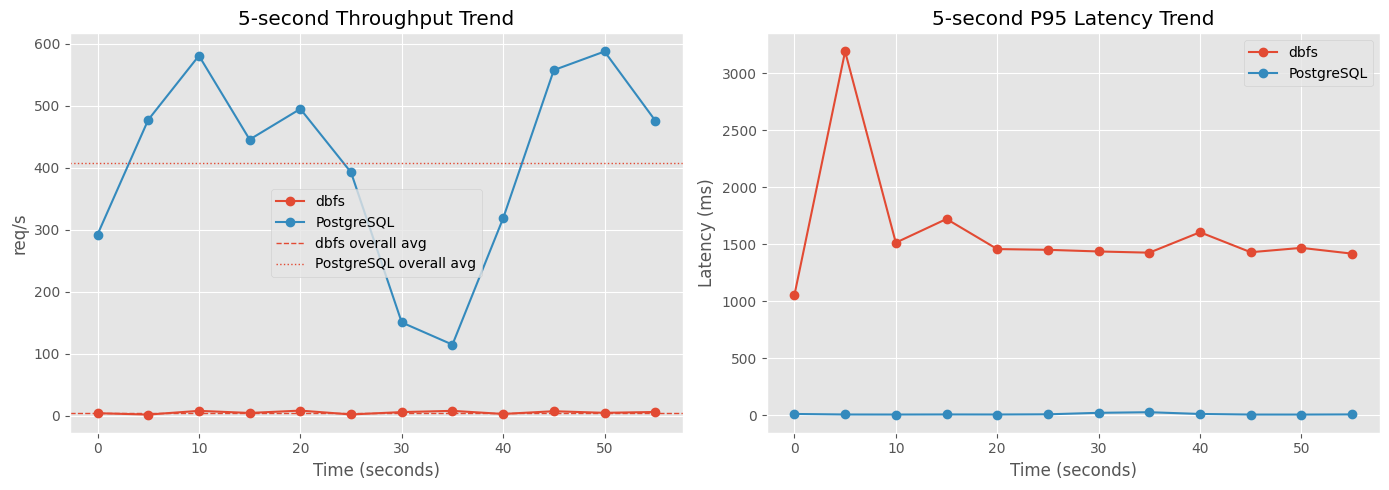

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for engine, run in runs.items():
    results_df = run['results_df']
    label = run['display_name']
    axes[0].plot(
        results_df['Time (seconds)'],
        results_df['Throughput (requests/second)'],
        marker='o',
        label=label,
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['95th Percentile Latency (millisecond)'],
        marker='o',
        label=label,
    )

axes[0].axhline(
    summary_comparison_df.loc['dbfs', 'Throughput (req/s)'],
    linestyle='--',
    linewidth=1,
    label='dbfs overall avg',
)
axes[0].axhline(
    summary_comparison_df.loc['PostgreSQL', 'Throughput (req/s)'],
    linestyle=':',
    linewidth=1,
    label='PostgreSQL overall avg',
)
axes[0].set_title('5-second Throughput Trend')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('req/s')
axes[0].legend()

axes[1].set_title('5-second P95 Latency Trend')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Latency (ms)')
axes[1].legend()

fig.tight_layout()
plt.show()

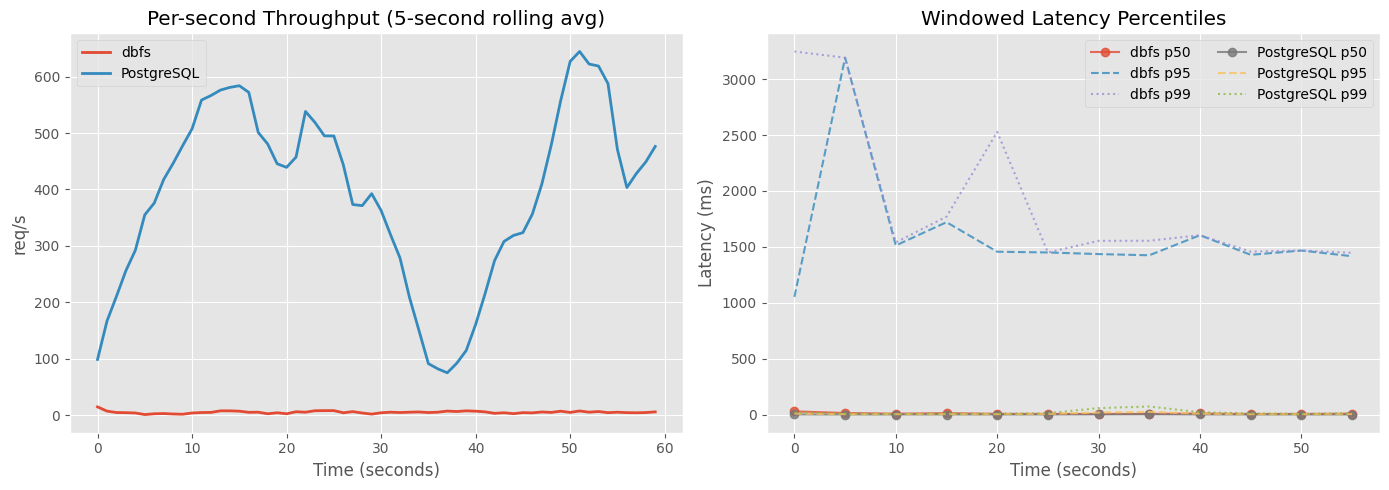

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for engine, run in runs.items():
    samples_df = run['samples_df'].copy()
    results_df = run['results_df']
    label = run['display_name']
    samples_df['Throughput Rolling'] = samples_df[
        'Throughput (requests/second)'].rolling(5, min_periods=1).mean()

    axes[0].plot(
        samples_df['Time (seconds)'],
        samples_df['Throughput Rolling'],
        linewidth=2,
        label=label,
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['Median Latency (millisecond)'],
        marker='o',
        alpha=0.8,
        label=f'{label} p50',
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['95th Percentile Latency (millisecond)'],
        linestyle='--',
        alpha=0.8,
        label=f'{label} p95',
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['99th Percentile Latency (millisecond)'],
        linestyle=':',
        alpha=0.8,
        label=f'{label} p99',
    )

axes[0].set_title('Per-second Throughput (5-second rolling avg)')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('req/s')
axes[0].legend()

axes[1].set_title('Windowed Latency Percentiles')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Latency (ms)')
axes[1].legend(ncol=2)

fig.tight_layout()
plt.show()

,Engine,Procedure,Avg Throughput (req/s),Avg Latency (ms),Avg P95 Latency (ms)
5,PostgreSQL,Delivery,16.783,7.621,16.997
0,dbfs,Delivery,0.233,988.930,"1,119.677"
6,PostgreSQL,NewOrder,187.267,4.189,9.132
1,dbfs,NewOrder,2.383,213.106,"1,358.201"
7,PostgreSQL,OrderStatus,15.983,1.644,4.803
2,dbfs,OrderStatus,0.300,65.629,68.358
8,PostgreSQL,Payment,171.633,1.887,5.316
3,dbfs,Payment,2.267,80.162,409.163
9,PostgreSQL,StockLevel,15.767,1.280,2.716
4,dbfs,StockLevel,0.217,57.830,58.680


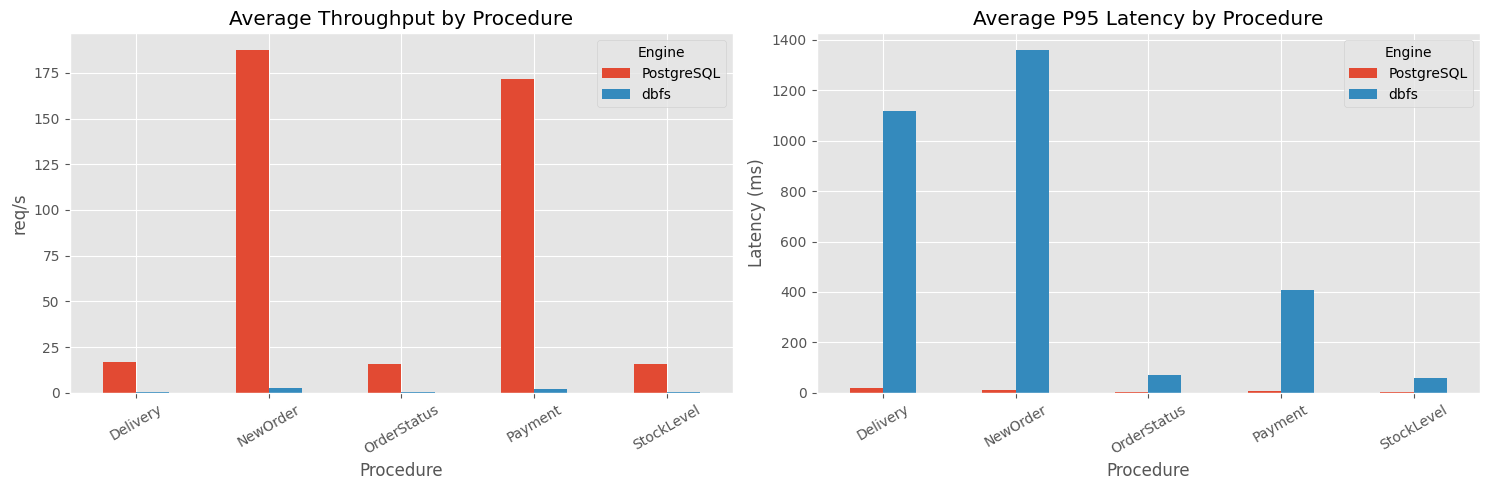

In [8]:
procedure_rows = []
for engine, run in runs.items():
    for procedure_name, procedure_df in run['procedure_dfs'].items():
        procedure_rows.append({
            'Engine':
            run['display_name'],
            'Procedure':
            procedure_name,
            'Avg Throughput (req/s)':
            procedure_df['Throughput (requests/second)'].mean(),
            'Avg Latency (ms)':
            procedure_df['Average Latency (millisecond)'].mean(),
            'Avg P95 Latency (ms)':
            procedure_df['95th Percentile Latency (millisecond)'].mean(),
        })

procedure_comparison_df = pd.DataFrame(procedure_rows).sort_values(
    ['Procedure', 'Engine'])
display(procedure_comparison_df)

procedure_throughput = procedure_comparison_df.pivot(
    index='Procedure', columns='Engine', values='Avg Throughput (req/s)')
procedure_p95 = procedure_comparison_df.pivot(index='Procedure',
                                              columns='Engine',
                                              values='Avg P95 Latency (ms)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
procedure_throughput.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Throughput by Procedure')
axes[0].set_ylabel('req/s')
axes[0].tick_params(axis='x', rotation=30)

procedure_p95.plot(kind='bar', ax=axes[1])
axes[1].set_title('Average P95 Latency by Procedure')
axes[1].set_ylabel('Latency (ms)')
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

In [9]:
mix_comparison_rows = []
for engine in transaction_mix_df['Engine'].unique():
    engine_mix = transaction_mix_df[transaction_mix_df['Engine'] ==
                                    engine].set_index('Transaction')
    for transaction_name, configured_ratio in configured_ratios.items():
        observed_ratio = engine_mix.loc[transaction_name, 'Observed Mix (%)']
        mix_comparison_rows.append({
            'Engine':
            engine,
            'Transaction':
            transaction_name,
            'Configured Ratio (%)':
            configured_ratio,
            'Observed Ratio (%)':
            observed_ratio,
            'Absolute Error (pp)':
            abs(observed_ratio - configured_ratio),
        })

mix_comparison_df = pd.DataFrame(mix_comparison_rows)
display(mix_comparison_df)

report_rows = []
for engine, run in runs.items():
    parsed = parse_terminal_log(run['terminal_log'])
    completed_total = transaction_mix_df.loc[transaction_mix_df['Engine'] ==
                                             run['display_name'],
                                             'Completed'].sum()
    aborted_total = transaction_mix_df.loc[
        transaction_mix_df['Engine'] == run['display_name'], 'Aborted'].sum()

    report_rows.append({
        'run_label':
        run['label'],
        'engine':
        run['display_name'],
        'dbms_type':
        parsed['dbms_type'],
        'workload':
        parsed['workload'],
        'scale_factor':
        float(parsed['scale_factor']),
        'terminals':
        int(parsed['terminals']),
        'duration_seconds':
        run['summary']['Elapsed Time (nanoseconds)'] / 1_000_000_000,
        'measured_requests':
        run['summary']['Measured Requests'],
        'throughput_req_per_s':
        run['summary']['Throughput (requests/second)'],
        'goodput_req_per_s':
        run['summary']['Goodput (requests/second)'],
        'completed_transactions':
        int(completed_total),
        'aborted_transactions':
        int(aborted_total),
        'abort_percentage':
        (aborted_total / (completed_total + aborted_total) * 100) if
        (completed_total + aborted_total) else 0.0,
    })

report_df = pd.DataFrame(report_rows)
display(report_df)

,Engine,Transaction,Configured Ratio (%),Observed Ratio (%),Absolute Error (pp)
0,dbfs,NewOrder,45.000,44.479,0.521
1,dbfs,Payment,43.000,41.718,1.282
2,dbfs,OrderStatus,4.000,5.521,1.521
3,dbfs,Delivery,4.000,4.294,0.294
4,dbfs,StockLevel,4.000,3.988,0.012
5,PostgreSQL,NewOrder,45.000,45.667,0.667
6,PostgreSQL,Payment,43.000,42.356,0.644
7,PostgreSQL,OrderStatus,4.000,3.944,0.056
8,PostgreSQL,Delivery,4.000,4.142,0.142
9,PostgreSQL,StockLevel,4.000,3.891,0.109


,run_label,engine,dbms_type,workload,scale_factor,terminals,duration_seconds,measured_requests,throughput_req_per_s,goodput_req_per_s,completed_transactions,aborted_transactions,abort_percentage
0,tpcc_2026-05-03_04-12-31,dbfs,POSTGRES,TPCC,1.000,1,61.382,324,5.278,5.311,326,0,0.000
1,tpcc_2026-05-03_04-14-31,PostgreSQL,POSTGRES,TPCC,1.000,1,60.000,24446,407.433,405.216,24313,134,0.548


Top query shapes for dbfs


,kind,executions,time_share_pct,total_elapsed_ms,mean_elapsed_ms,p95_elapsed_ms,max_elapsed_ms,failures,sample_sql
0,UPDATE,300040,49.986,"59,029.550",0.196,<NA>,"2,318.419",0,"INSERT INTO order_line VALUES (1, 1, 1, 1, 200..."
1,UPDATE,140,7.271,"8,586.994",61.335,<NA>,"1,825.072",0,UPDATE order_line SET OL_DELIVERY_D = '2026-05...
2,QUERY,1358,6.305,"7,445.932",5.483,<NA>,"1,514.506",0,"SELECT S_QUANTITY, S_DATA, S_DIST_01, S_DIST_0..."
3,QUERY,140,5.658,"6,681.869",47.727,<NA>,308.785,0,SELECT SUM(OL_AMOUNT) AS OL_TOTAL FROM order_l...
4,UPDATE,100000,4.218,"4,981.063",0.049,<NA>,88.471,0,"INSERT INTO stock VALUES (1, 1, 37, 0.0, 0, 0,..."
5,UPDATE,30000,3.982,"4,702.779",0.156,<NA>,704.305,0,"INSERT INTO customer VALUES (1, 1, 1, 0.460500..."
6,QUERY,1358,3.892,"4,596.668",3.384,<NA>,"1,563.738",0,"SELECT I_PRICE, I_NAME , I_DATA FROM item WHER..."
7,UPDATE,1358,3.820,"4,511.061",3.321,<NA>,"1,472.277",0,"UPDATE stock SET S_QUANTITY = 54 , S_YTD = S_Y..."
8,UPDATE,100000,2.430,"2,869.338",0.028,<NA>,64.824,0,"INSERT INTO item VALUES (1, 'sxvnjhpdqdxvc', 5..."
9,QUERY,140,1.899,"2,242.466",16.017,<NA>,"2,213.896",0,SELECT O_C_ID FROM oorder WHERE O_ID = 2101 AN...


Top query shapes for PostgreSQL


,kind,executions,time_share_pct,total_elapsed_ms,mean_elapsed_ms,p95_elapsed_ms,max_elapsed_ms,failures,sample_sql
0,QUERY,2344,27.024,"10,656.288",4.546,<NA>,20.104,0,"INSERT INTO order_line VALUES ($1, $2, $3, $4,..."
1,QUERY,512378,26.854,"10,589.423",0.021,<NA>,6.850,0,"SELECT $4 FROM ONLY ""public"".""customer"" x WHER..."
2,QUERY,6765,7.857,"3,098.215",0.458,<NA>,54.759,0,"SELECT C_FIRST, C_MIDDLE, C_ID, C_STREET_1, C_..."
3,QUERY,8016,5.021,"1,979.832",0.247,<NA>,6.502,0,"INSERT INTO order_line\n (OL_O_ID, OL_D_ID..."
4,QUERY,111892,4.245,"1,673.931",0.015,<NA>,775.100,0,"SELECT I_PRICE, I_NAME , I_DATA\n FROM it..."
5,QUERY,111758,3.047,"1,201.580",0.011,<NA>,8.461,0,"SELECT S_QUANTITY, S_DATA, S_DIST_01, S_DIST_0..."
6,QUERY,480904,2.659,"1,048.593",0.002,<NA>,2.627,0,"SELECT $3 FROM ONLY ""public"".""district"" x WHER..."
7,QUERY,781,2.551,"1,006.116",1.288,<NA>,5.202,0,"INSERT INTO stock VALUES ($1, $2, $3, $4, $5, ..."
8,QUERY,7050,2.208,870.751,0.124,<NA>,3.000,0,"INSERT INTO order_line\n (OL_O_ID, OL_D_ID..."
9,QUERY,946,1.879,741.107,0.783,<NA>,17.637,0,SELECT COUNT(DISTINCT (S_I_ID)) AS STOCK_COUNT...


/var/folders/fb/ffh7t7rs47jgclbwtxyfr75w0000gn/T/ipykernel_80904/3687218545.py:116: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


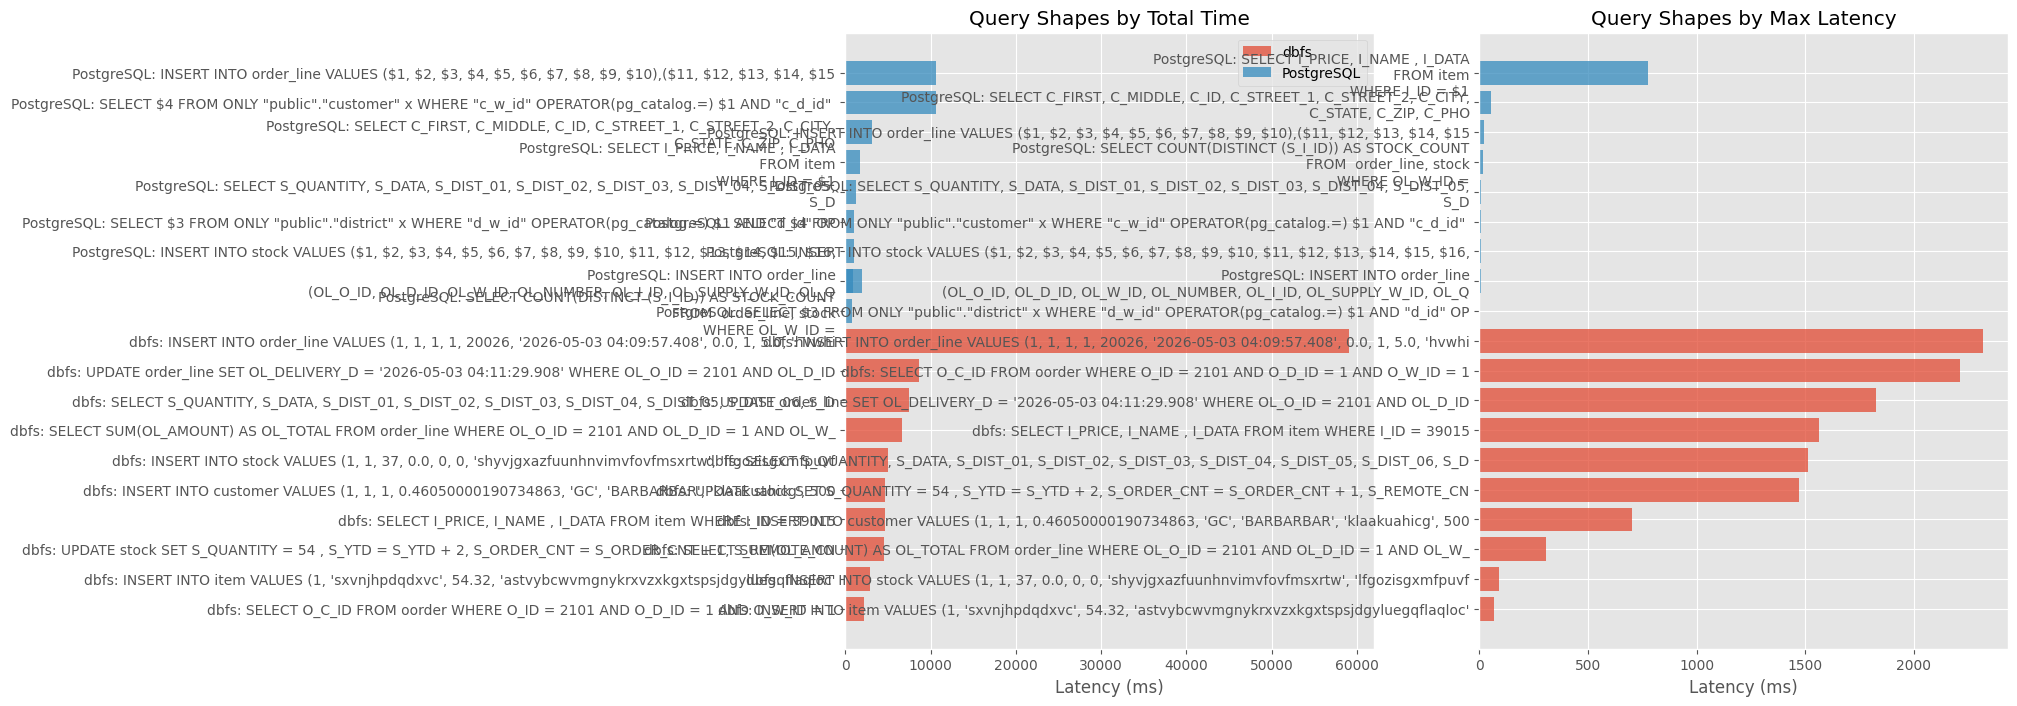

In [11]:
def summarize_dbfs_query_trace(trace_df):
    summary_df = trace_df.copy()
    summary_df['sample_sql'] = summary_df['sample_sql'].fillna(
        summary_df['shape_key'])
    summary_df['total_elapsed_ms'] = summary_df['total_elapsed_us'] / 1000.0
    summary_df['mean_elapsed_ms'] = summary_df['mean_elapsed_us'] / 1000.0
    summary_df['p95_elapsed_ms'] = pd.NA
    summary_df['max_elapsed_ms'] = summary_df['max_elapsed_us'] / 1000.0
    summary_df = summary_df.sort_values(['total_elapsed_ms', 'executions'],
                                        ascending=[False, False])
    return summary_df[[
        'kind',
        'shape_key',
        'sample_sql',
        'executions',
        'total_elapsed_ms',
        'mean_elapsed_ms',
        'p95_elapsed_ms',
        'max_elapsed_ms',
        'failures',
    ]]


def summarize_postgres_query_trace(trace_df):
    summary_df = trace_df.copy()
    summary_df['kind'] = 'QUERY'
    summary_df['shape_key'] = summary_df['query'].str.replace(
        r'\s+', ' ', regex=True).str.strip()
    summary_df['sample_sql'] = summary_df['query']
    summary_df['executions'] = summary_df['calls']
    summary_df['total_elapsed_ms'] = summary_df['total_exec_time']
    summary_df['mean_elapsed_ms'] = summary_df['mean_exec_time']
    summary_df['p95_elapsed_ms'] = pd.NA
    summary_df['max_elapsed_ms'] = summary_df['max_exec_time']
    summary_df['failures'] = 0
    summary_df = summary_df.sort_values(['total_elapsed_ms', 'executions'],
                                        ascending=[False, False])
    return summary_df[[
        'kind',
        'shape_key',
        'sample_sql',
        'executions',
        'total_elapsed_ms',
        'mean_elapsed_ms',
        'p95_elapsed_ms',
        'max_elapsed_ms',
        'failures',
    ]]


def escape_plot_label(text):
    return text.replace('$', r'\$')


trace_summaries = {}
for engine, run in runs.items():
    trace_df = run['query_trace_df']
    if trace_df is None or trace_df.empty:
        print(
            f"{run['display_name']}: {query_trace_filenames[engine]} was not found."
        )
        continue

    if engine == 'dbfs':
        engine_summary_df = summarize_dbfs_query_trace(trace_df.copy())
    else:
        engine_summary_df = summarize_postgres_query_trace(trace_df.copy())

    engine_summary_df['Engine'] = run['display_name']
    engine_summary_df['time_share_pct'] = (
        engine_summary_df['total_elapsed_ms'] /
        engine_summary_df['total_elapsed_ms'].sum() * 100)
    engine_summary_df['label'] = engine_summary_df['sample_sql'].str.slice(
        0, 96)
    engine_summary_df['plot_label'] = engine_summary_df['label'].map(
        escape_plot_label)
    trace_summaries[engine] = engine_summary_df

for engine, summary_df in trace_summaries.items():
    display_name = runs[engine]['display_name']
    print(f'Top query shapes for {display_name}')
    display(summary_df[[
        'kind',
        'executions',
        'time_share_pct',
        'total_elapsed_ms',
        'mean_elapsed_ms',
        'p95_elapsed_ms',
        'max_elapsed_ms',
        'failures',
        'sample_sql',
    ]].head(15))

if trace_summaries:
    fig, axes = plt.subplots(1, 2, figsize=(15, 8))

    for axis, metric, title in [
        (axes[0], 'total_elapsed_ms', 'Query Shapes by Total Time'),
        (axes[1], 'max_elapsed_ms', 'Query Shapes by Max Latency'),
    ]:
        for engine, summary_df in trace_summaries.items():
            top_df = summary_df.head(10).sort_values(metric)
            axis.barh(
                [
                    f"{runs[engine]['display_name']}: {label}"
                    for label in top_df['plot_label']
                ],
                top_df[metric],
                alpha=0.75,
                label=runs[engine]['display_name'],
            )
        axis.set_title(title)
        axis.set_xlabel('Latency (ms)')

    axes[0].legend()
    fig.tight_layout()
    plt.show()

## Comparison Notes

Conclusion template:

- PostgreSQL shows a large throughput advantage over dbfs under the same TPCC configuration.
- dbfs completed the same workload shape without unexpected SQL errors, which means the current SQL support is sufficient for this TPCC slice.
- The main next step is performance-oriented investigation: loader behavior, per-procedure latency spikes, and the gap between dbfs and PostgreSQL throughput.
- If `dbfs_query_trace.csv` and `postgres_query_trace.csv` are present in the result directories, the notebook also ranks query shapes by total time, mean latency, and max latency to highlight bottlenecks on each engine.